# Emulators

Emulators are core components of the history matching algorithm. An emulator is a function that allows us to predict the output of a model for a set of input parameters, along with some uncertainty measures. An important characteristic of an emulator is that its execution time is much faster than the execution time of a model. The `emulators` module of our package contains some emulators. Here we describe how to use the emulators included in the `history_matching` package. 

## Libraries, global parameters, and initialization

The basic libraries for numerical analysis are used throughout the notebook, namely, numpy and pandas. We also use the `emulator` module from our library.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import history_matching.emulators as emulators

%matplotlib inline




Loaded tensorflow-probability version 0.24.0.
Loaded tensorflow-probability version 0.24.0.


## Example scenario: Linear model

Let's define a linear model in 1 dimension. In its simplest form, this model receives a single parameter $\theta$
 and outputs a scalar. This scalar is computed as $b_0 + b_1 \theta + \mathcal{N}(0, \sigma)$, with $b_0$, $b_1$, and $\sigma$ being hyper-parameters that, for all the purposes in this example, are constant (and unknown to an emulator).

In the Python function that implements this model, we extend this definition and apply it to a set of parameters $\theta$, which are defined as separate rows of an input dataframe x. Consequently, this function computes the corresponding outputs and returns them in an output dataframe.

In [2]:
def linear_model( x: pd.DataFrame(), b0=1, b1=2, sigma=7.5 ):
    """
    1-D linear model. Using the value of theta in each row of the 
    input dataframe, the model computes outputs in an output dataframe
    as: 
            b0 + b1*theta + mu,
    with mu being drawn from a 0-mean normal distribution with standard
    deviation sigma.
    """
    y = b0 + b1*x['theta'] + np.random.normal( 0, sigma, len(x) )
    y = y.to_frame( name='out' )
    y.index = x.index
    return y

Now, let's see how this model works. We can do that by defining the parameter space as the interval [`theta_min`, `theta_max`], and then sampling some points in that space. We then call our model and plot the outputs. As expected in this case, we see that the output is a noisy line.

<Axes: title={'center': 'Linear model'}, xlabel='theta', ylabel='data'>

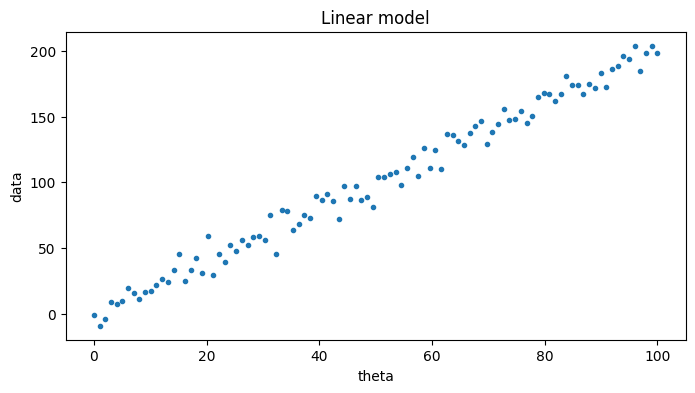

In [3]:
# Sample parameters from a grid
theta_min = 0
theta_max = 100
n = 100
x = pd.DataFrame( { 'theta' : np.linspace( theta_min, theta_max, n ) } )

# Run the model and plot outputs
y = linear_model(x)
xy_model = pd.DataFrame( { 'theta' : x['theta'].values,
                           'data'  : y['out'].values
                          } )

xy_model.plot( title='Linear model', x='theta', y='data', ylabel='data', legend=False, style='.', figsize=(8,4))

## Working with a linear model emulator

One of the most basic emulators is the linear regression emulator. This emulator is defined by the `emulators.LinearModel` class.

We can train our emulator by instantiating it with some input data (such as the one created above using the linear model), and then calling th`e train`() method, as follows: